In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor

import mlflow
import mlflow.xgboost

import joblib

In [3]:
import seaborn as sns 
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv('data/california_housing.csv')
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [5]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [7]:
xgb_model = XGBRegressor(
    random_state=42
)

In [8]:
param_grid = {
    "n_estimators": [100, 200],

    "max_depth": [4, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0]
}

In [9]:
grid_search = GridSearchCV(
    estimator=xgb_model,

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    verbose=2,

    n_jobs=-1
)

In [10]:
mlflow.set_experiment("Housing_XGBoost")

2026/05/09 20:37:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 20:37:33 INFO mlflow.store.db.utils: Updating database tables
2026/05/09 20:37:35 INFO mlflow.tracking.fluent: Experiment with name 'Housing_XGBoost' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///y:/code/machine_learning/boston_house_pricing/mlruns/1', creation_time=1778333855689, experiment_id='1', last_update_time=1778333855689, lifecycle_stage='active', name='Housing_XGBoost', tags={}, trace_location=None, workspace='default'>

In [17]:
with mlflow.start_run():

    # Train GridSearch
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_

    # Predict
    predictions = best_model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    # =========================
    # Round metrics
    # =========================
    mse = round(mse, 2)

    rmse = round(rmse, 2)

    mae = round(mae, 2)

    r2 = round(r2, 2)

    # =========================
    # Log best parameters
    # =========================
    mlflow.log_params(grid_search.best_params_)

    # =========================
    # Log metrics
    # =========================
    mlflow.log_metric("MSE", mse)

    mlflow.log_metric("RMSE", rmse)

    mlflow.log_metric("MAE", mae)

    mlflow.log_metric("R2", r2)

    # =========================
    # Log model
    # =========================
    mlflow.xgboost.log_model(
        best_model,
        "xgboost_model"
    )

    # =========================
    # Save model locally
    # =========================
    joblib.dump(
        best_model,
        "models/best_xgboost/best_xgboost_02.pkl"
    )

    # =========================
    # Print results
    # =========================
    print("\n===== BEST PARAMETERS =====")

    print(grid_search.best_params_)

    print("\n===== METRICS =====")

    print(f"MSE  : {mse:.2f}")

    print(f"RMSE : {rmse:.2f}")

    print(f"MAE  : {mae:.2f}")

    print(f"R2   : {r2:.2f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits


2026/05/09 20:51:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



===== BEST PARAMETERS =====
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}

===== METRICS =====
MSE  : 0.20
RMSE : 0.45
MAE  : 0.29
R2   : 0.85


In [18]:
sns.set_theme(style="darkgrid", palette="pastel")

In [19]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

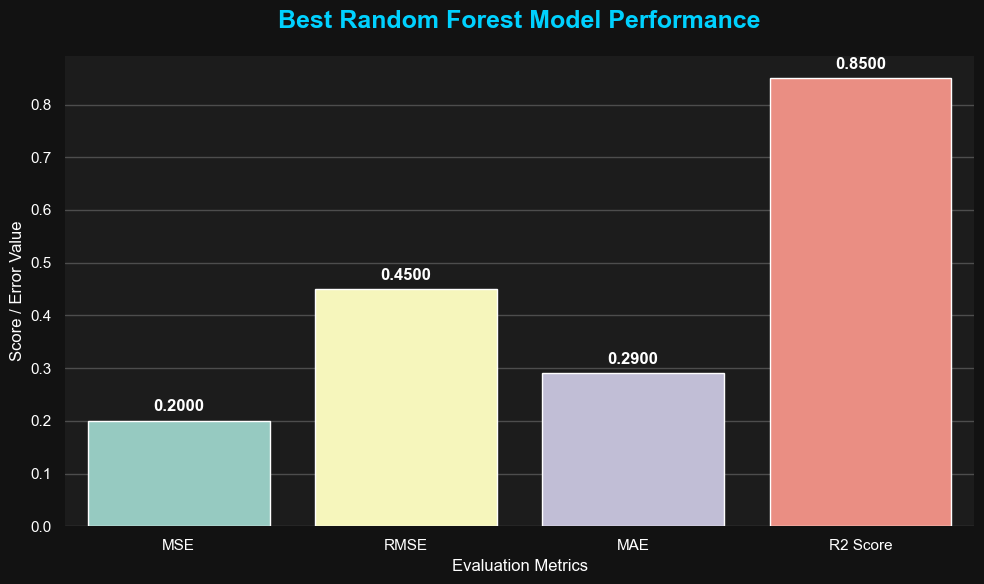

In [20]:
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2 Score'],
    'Value': [mse, rmse, mae, r2]
}
df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Metric', 
    y='Value', 
    data=df_metrics, 
    hue='Metric',       
    palette='Set3',    
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                color='white',
                fontsize=12,
                fontweight='bold')

plt.title('Best Random Forest Model Performance', fontsize=18, fontweight='bold', color='#00d1ff', pad=20)
plt.ylabel('Score / Error Value')
plt.xlabel('Evaluation Metrics')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("reports/images/best_xgboost_results/performance.png")
plt.show()

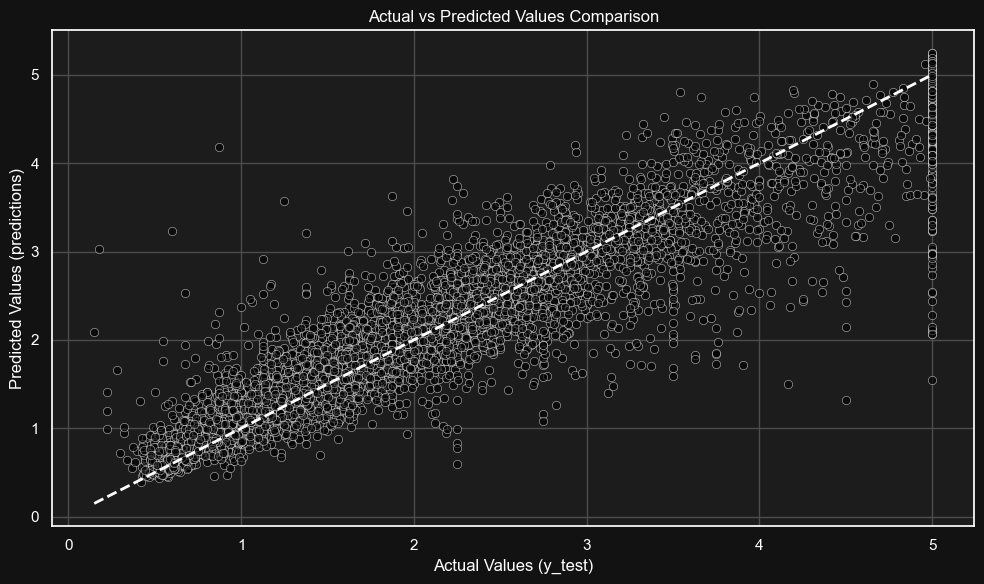

In [29]:
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    x=y_test,
    y=predictions,
    alpha=0.6,
    color='black',
    edgecolor='w'
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='white',
    lw=2,
    linestyle='--'
)

# Labels
plt.xlabel('Actual Values (y_test)')

plt.ylabel('Predicted Values (predictions)')

# Title
plt.title('Actual vs Predicted Values Comparison')

# Layout
plt.tight_layout()

# Save image
plt.savefig(
    "reports/images/best_xgboost_results/actual_predicted_scatter.png"
)

# Show plot
plt.show()

# **Residuals**

In [25]:
residuals = y_test - predictions

In [26]:
residuals

20046   -0.061919
3024    -0.362599
15663   -0.097077
20484   -0.233501
9814     0.408326
           ...   
17505    0.171073
13512    0.027885
10842   -0.228287
16559   -0.189854
5786     0.072456
Name: Price, Length: 6192, dtype: float64

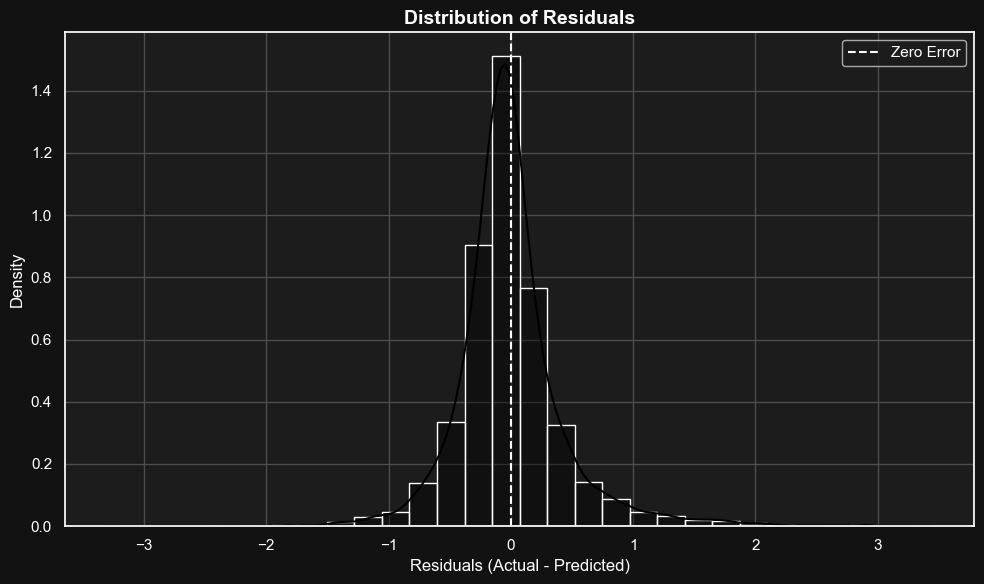

In [30]:
plt.figure(figsize=(10, 6))

# Improve the plot by combining a histogram with a KDE curve
# kde=True: Adds the kernel density estimate line
# stat="density": Normalizes the histogram so the area equals 1
sns.histplot(residuals, kde=True, color='black', bins=30, stat="density", alpha=0.4)

# Add a vertical dashed line at 0
# Ideally, residuals should be normally distributed around zero
plt.axvline(x=0, color='white', linestyle='--', label='Zero Error')

# Labeling for clarity
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig("reports/images/best_xgboost_results/residuals.png")
plt.show()

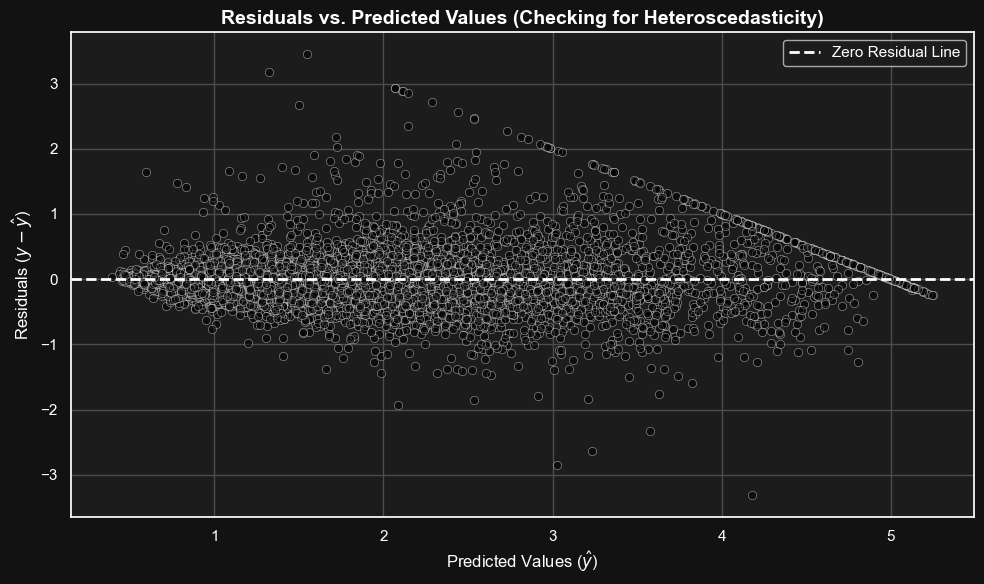

In [31]:
# Scatter plot with respect to prediction and residuals
plt.figure(figsize=(10, 6))

# Use sns.scatterplot for better control over aesthetics
sns.scatterplot(x=predictions, y=residuals, alpha=0.5, color='black', edgecolor='w')

# Add a horizontal line at y=0
plt.axhline(y=0, color='white', linestyle='--', linewidth=2, label='Zero Residual Line')

# FIX: Use 'r' before the string to avoid SyntaxWarning with LaTeX backslashes
plt.xlabel(r'Predicted Values ($\hat{y}$)', fontsize=12)
plt.ylabel(r'Residuals ($y - \hat{y}$)', fontsize=12)

plt.title('Residuals vs. Predicted Values (Checking for Heteroscedasticity)', fontsize=14, fontweight='bold')
plt.legend()
plt.savefig("reports/images/best_xgboost_results/prediction_residuals_scatter.png")
plt.tight_layout()
plt.show()

In [34]:
# Load saved model
xgb_model = joblib.load("models/best_xgboost/best_xgboost_02.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [35]:
sample = pd.DataFrame({
    "MedInc": [8.3252],
    "HouseAge": [41.0],
    "AveRooms": [6.9841],
    "AveBedrms": [1.0238],
    "Population": [322.0],
    "AveOccup": [2.5556],
    "Latitude": [37.88],
    "Longitude": [-122.23]
})

result = xgb_model.predict(sample)

print("\nPredicted Price:", result[0])


Predicted Price: 4.4414763
